# Phase 4 — CARLA 통합 평가 파이프라인
## Detection + Segmentation + Depth + Tracking 전체 통합

### 실행 전 체크리스트
- [ ] CARLA 서버 실행: `CarlaUE4.exe -quality-level=Low`
- [ ] 데이터 수집 완료: `python carla_data_collector.py --frames 500`
- [ ] 커널: **Python (carla_env)**

### 이 노트북이 하는 것
```
CARLA 수집 데이터
  ├─ RGB 이미지  → YOLOv8 Detection  → mAP  (GT: CARLA actor bbox)
  ├─ RGB 이미지  → SAM2 Segmentation → mIoU (GT: CARLA semantic mask)
  ├─ Depth GT   → DepthAnythingV2   → RMSE / δ1 (절대 미터 비교)
  ├─ RGB 시퀀스 → ByteTrack         → MOTA
  └─ 전체 결과  → 대시보드 요약
```

### Phase 1~3 수치와 비교
| 모델 | Phase 1~3 (COCO/합성) | Phase 4 (CARLA GT) |
|------|----------------------|--------------------|
| Detection mAP | ~0.6x | 측정 예정 |
| Seg mIoU | 0.694 (Point vs Box) | 측정 예정 |
| Depth RMSE | 0.16m (합성 GT) | 측정 예정 |
| Tracking MOTA | 0.9412 (시뮬) | 측정 예정 |

## 0. 환경 확인 + 데이터 로드

In [16]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'filterpy', '-q'])

import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import numpy as np
import cv2
import json
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')

PROJECT_ROOT = Path('C:/Users/apple/Desktop/autonomous_cv_pipeline')
DATA_DIR     = PROJECT_ROOT / 'phase4_carla' / 'data_collection' / 'carla_dataset'

# 데이터 확인
img_dir = DATA_DIR / 'images'
dep_dir = DATA_DIR / 'depth'
sem_dir = DATA_DIR / 'semantic'
lbl_dir = DATA_DIR / 'labels'

img_files = sorted(img_dir.glob('*.jpg'))
print(f'\nCARLA 데이터셋:')
print(f'  이미지   : {len(img_files)}장')
print(f'  깊이 맵  : {len(list(dep_dir.glob("*.npy")))}개')
print(f'  시맨틱   : {len(list(sem_dir.glob("*.png")))}개')
print(f'  레이블   : {len(list(lbl_dir.glob("*.txt")))}개')

# 메타데이터 로드
with open(DATA_DIR / 'metadata.json') as f:
    meta = json.load(f)
K = np.array(meta['camera_intrinsics'])
print(f'\n카메라 파라미터:')
print(f'  해상도: {meta["image_size"]}')
print(f'  FOV   : {meta["fov"]}°')
print(f'  fx    : {K[0,0]:.1f}px')
print(f'  수집일: {meta["collected_at"]}')

# ── 박스 있는 프레임만 필터링 ──
def has_gt_box(img_f):
    lbl = lbl_dir / f'{img_f.stem}.txt'
    if not lbl.exists(): return False
    lines = [l.strip() for l in lbl.read_text().splitlines() if l.strip()]
    return len(lines) > 0

eval_img_files = [f for f in img_files if has_gt_box(f)]
print(f'GT 박스 있는 프레임: {len(eval_img_files)}개 / {len(img_files)}개')


PyTorch : 2.6.0+cu124
CUDA    : True (NVIDIA GeForce RTX 4080 SUPER)

CARLA 데이터셋:
  이미지   : 500장
  깊이 맵  : 500개
  시맨틱   : 500개
  레이블   : 500개

카메라 파라미터:
  해상도: [1280, 720]
  FOV   : 90°
  fx    : 640.0px
  수집일: 2026-03-29T22:46:43.817139
GT 박스 있는 프레임: 174개 / 500개


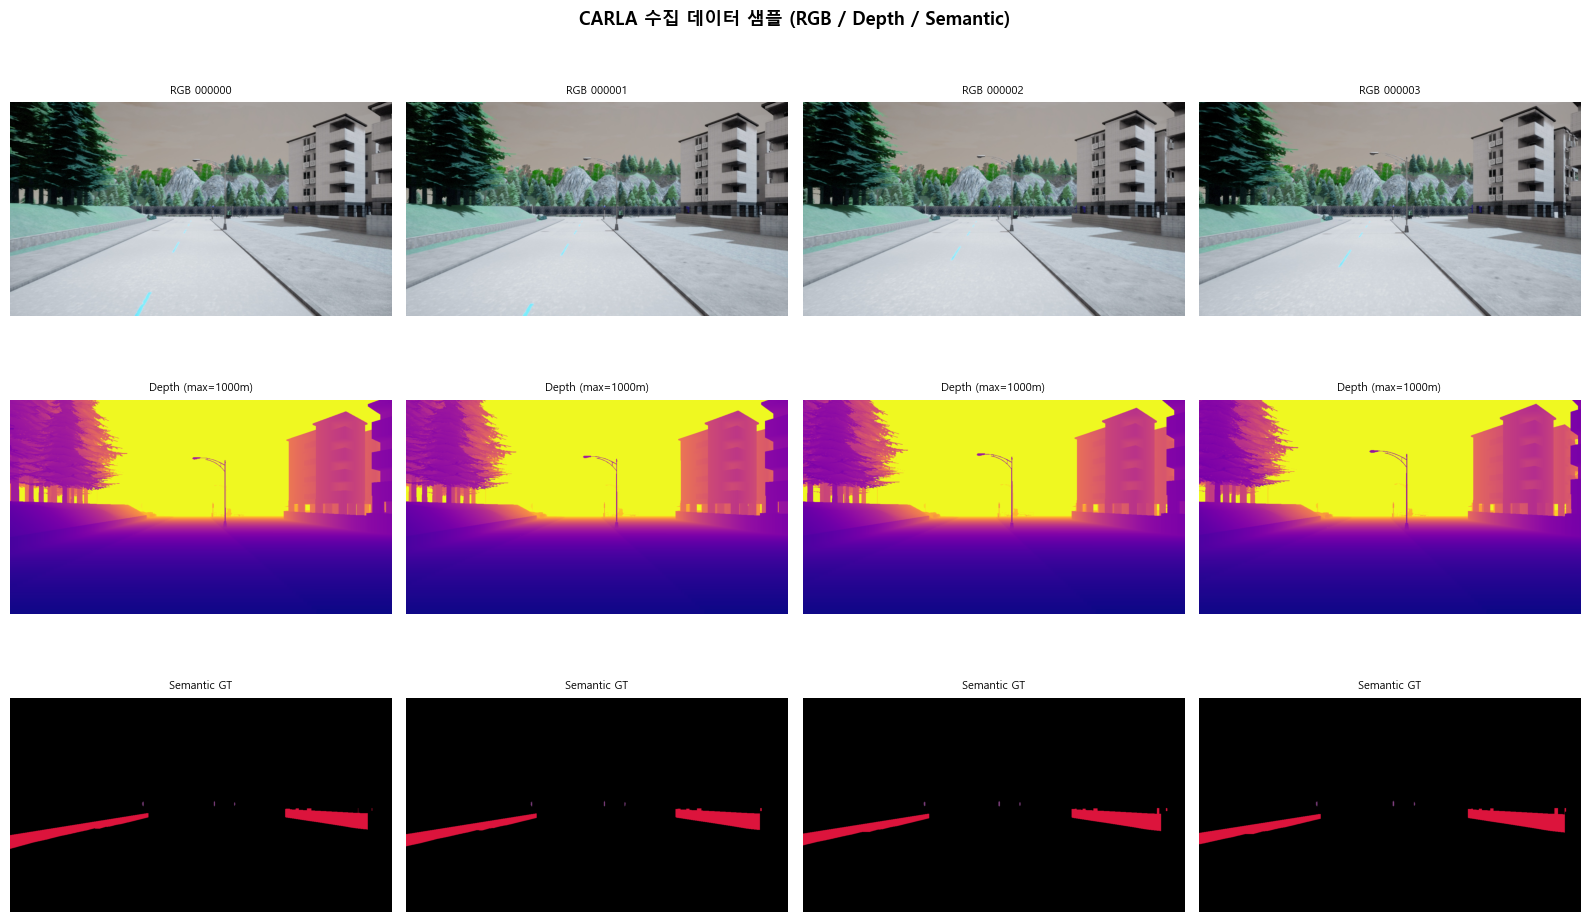

In [17]:
# ── 샘플 프레임 시각화 ──
n_show = min(4, len(img_files))
fig, axes = plt.subplots(3, n_show, figsize=(4*n_show, 10))

CARLA_SEMANTIC_COLORS = {
    0:(0,0,0), 4:(220,20,60), 7:(128,64,128), 10:(0,0,142),
    12:(220,220,0), 18:(250,170,30)
}

for col, img_f in enumerate(img_files[:n_show]):
    stem = img_f.stem

    # RGB
    img = cv2.cvtColor(cv2.imread(str(img_f)), cv2.COLOR_BGR2RGB)
    axes[0][col].imshow(img)
    axes[0][col].set_title(f'RGB {stem}', fontsize=8)
    axes[0][col].axis('off')

    # Depth
    dep = np.load(str(dep_dir / f'{stem}.npy'))
    dep_clip = np.clip(dep, 0, 50)  # 50m 클리핑
    axes[1][col].imshow(dep_clip, cmap='plasma')
    axes[1][col].set_title(f'Depth (max={dep.max():.0f}m)', fontsize=8)
    axes[1][col].axis('off')

    # Semantic — CARLA semantic PNG: R채널 = class ID
    # GRAYSCALE로 읽으면 R*0.114 + G*0.587 + B*0.299 변환 → class ID 손실
    sem_bgr = cv2.imread(str(sem_dir / f'{stem}.png'))
    sem = sem_bgr[:, :, 2]  # R채널만 추출 (class ID)
    H, W = sem.shape
    sem_rgb = np.zeros((H, W, 3), dtype=np.uint8)
    for cls_id, color in CARLA_SEMANTIC_COLORS.items():
        sem_rgb[sem == cls_id] = color
    axes[2][col].imshow(sem_rgb)
    axes[2][col].set_title('Semantic GT', fontsize=8)
    axes[2][col].axis('off')

axes[0][0].set_ylabel('RGB', fontsize=9)
axes[1][0].set_ylabel('Depth GT (m)', fontsize=9)
axes[2][0].set_ylabel('Semantic GT', fontsize=9)
plt.suptitle('CARLA 수집 데이터 샘플 (RGB / Depth / Semantic)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1. Detection 평가 — YOLOv8 vs CARLA GT BBox

CARLA actor에서 자동 생성된 GT 바운딩 박스 vs YOLOv8 예측 → **mAP@IoU 직접 계산**

In [18]:
from ultralytics import YOLO

det_model = YOLO(PROJECT_ROOT / 'phase1_basics/detection/runs/detect/coco128_finetune/weights/best.pt')
print('YOLOv8 파인튜닝 모델 로드 완료')

COCO_NAMES = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck',
    'boat','traffic light','fire hydrant','stop sign','parking meter','bench',
    'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
    'backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
    'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard',
    'tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl',
    'banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza',
    'donut','cake','chair','couch','potted plant','bed','dining table','toilet',
    'tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven',
    'toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
    'hair drier','toothbrush'
]
CARLA_TO_COCO = {0: 0, 2: 2}  # CARLA person→0, car→2


def load_gt_boxes(lbl_path: Path, img_w: int, img_h: int) -> list:
    """YOLO 형식 GT 레이블 → 절대 좌표 반환"""
    boxes = []
    if not lbl_path.exists():
        return boxes
    with open(lbl_path) as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, w, h = parts[1:5]
            x1 = (cx - w/2) * img_w
            y1 = (cy - h/2) * img_h
            x2 = (cx + w/2) * img_w
            y2 = (cy + h/2) * img_h
            boxes.append({'cls': cls_id, 'box': [x1, y1, x2, y2]})
    return boxes


def box_iou(b1, b2) -> float:
    """두 박스의 IoU 계산"""
    x1 = max(b1[0], b2[0]); y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2]); y2 = min(b1[3], b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (area1 + area2 - inter + 1e-8)


# ── 평가 실행 ──
print('Detection 평가 중...')
eval_imgs = eval_img_files[:100]  # 100장 평가
all_det_results = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
iou_threshold = 0.5

for img_f in eval_imgs:
    img = cv2.imread(str(img_f))
    H, W = img.shape[:2]
    gt_boxes = load_gt_boxes(lbl_dir / f'{img_f.stem}.txt', W, H)
    if not gt_boxes:
        continue

    res = det_model(str(img_f), verbose=False, conf=0.25)
    pred_boxes = []
    if res[0].boxes is not None:
        for box in res[0].boxes:
            pred_boxes.append({
                'cls': int(box.cls[0]),
                'conf': float(box.conf[0]),
                'box': box.xyxy[0].tolist()
            })

    # 매칭: GT별로 best pred 찾기
    matched_pred = set()
    for gt in gt_boxes:
        best_iou, best_pi = 0, -1
        for pi, pred in enumerate(pred_boxes):
            if pred['cls'] != gt['cls'] or pi in matched_pred:
                continue
            iou = box_iou(gt['box'], pred['box'])
            if iou > best_iou:
                best_iou, best_pi = iou, pi
        if best_iou >= iou_threshold:
            all_det_results[gt['cls']]['tp'] += 1
            matched_pred.add(best_pi)
        else:
            all_det_results[gt['cls']]['fn'] += 1
    for pi, pred in enumerate(pred_boxes):
        if pi not in matched_pred:
            all_det_results[pred['cls']]['fp'] += 1

print(f'\n[Detection 결과] (IoU@{iou_threshold}, {len(eval_imgs)}장)')
print(f'{"클래스":<15} {"TP":>6} {"FP":>6} {"FN":>6} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 65)
all_prec, all_rec = [], []
for cls_id, stats in sorted(all_det_results.items()):
    tp, fp, fn = stats['tp'], stats['fp'], stats['fn']
    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2*prec*rec / (prec+rec+1e-8)
    cls_name = COCO_NAMES[cls_id] if cls_id < len(COCO_NAMES) else str(cls_id)
    print(f'{cls_name:<15} {tp:>6} {fp:>6} {fn:>6} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}')
    all_prec.append(prec); all_rec.append(rec)
print('-' * 65)
print(f'{"[평균]":<15} {"":>6} {"":>6} {"":>6} {np.mean(all_prec):>10.4f} {np.mean(all_rec):>8.4f}')

YOLOv8 파인튜닝 모델 로드 완료
Detection 평가 중...

[Detection 결과] (IoU@0.5, 100장)
클래스                 TP     FP     FN  Precision   Recall       F1
-----------------------------------------------------------------
car                 22     28     98     0.4400   0.1833   0.2588
bus                  0      3      0     0.0000   0.0000   0.0000
truck                0      1      0     0.0000   0.0000   0.0000
boat                 0      3      0     0.0000   0.0000   0.0000
traffic light        0      5      0     0.0000   0.0000   0.0000
stop sign            0      1      0     0.0000   0.0000   0.0000
-----------------------------------------------------------------
[평균]                                     0.0733   0.0306


## 2. Depth 평가 — DepthAnythingV2 vs CARLA 깊이 GT (절대 미터)

Phase 1에서는 합성 GT를 사용했으나, 여기서는 **CARLA depth sensor가 제공하는 실제 미터 단위 GT**와 비교.

In [19]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
from PIL import Image

MODEL_ID = 'depth-anything/Depth-Anything-V2-Small-hf'
processor   = AutoImageProcessor.from_pretrained(MODEL_ID)
depth_model = AutoModelForDepthEstimation.from_pretrained(MODEL_ID)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
depth_model = depth_model.to(device).eval()
print(f'DepthAnythingV2 로드 완료 → {device}')


def predict_depth(img_path: str) -> np.ndarray:
    """이미지 → 상대 깊이 맵 (정규화 0~1, 클수록 가까움)"""
    img_pil = Image.open(img_path).convert('RGB')
    inputs  = processor(images=img_pil, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = depth_model(**inputs)
    depth = torch.nn.functional.interpolate(
        outputs.predicted_depth.unsqueeze(1),
        size=img_pil.size[::-1], mode='bilinear', align_corners=False
    ).squeeze().cpu().numpy()
    return depth


def align_scale_shift(pred: np.ndarray, gt: np.ndarray, mask: np.ndarray = None):
    """최소제곱법으로 pred 스케일 정렬"""
    if mask is None:
        mask = np.ones_like(gt, dtype=bool)
    p = pred[mask].flatten()
    g = gt[mask].flatten()
    A = np.stack([p, np.ones_like(p)], axis=1)
    s, t = np.linalg.lstsq(A, g, rcond=None)[0]
    return pred * s + t


def compute_depth_metrics(pred_m: np.ndarray, gt_m: np.ndarray, max_depth: float = 50.0):
    """RMSE / AbsRel / δ1 / SI-RMSE 계산"""
    valid = (gt_m > 0.5) & (gt_m < max_depth)
    p, g = pred_m[valid], gt_m[valid]
    rmse   = float(np.sqrt(np.mean((p - g)**2)))
    absrel = float(np.mean(np.abs(p - g) / (g + 1e-8)))
    delta1 = float((np.maximum(p/(g+1e-8), g/(p+1e-8)) < 1.25).mean())
    lp = np.log(np.clip(p, 1e-8, None))
    lg = np.log(np.clip(g, 1e-8, None))
    d  = lp - lg
    si_rmse = float(np.sqrt(np.mean(d**2) - 0.5*np.mean(d)**2))
    return {'rmse': rmse, 'absrel': absrel, 'delta1': delta1, 'si_rmse': si_rmse}


# ── 평가 실행 ──
print('Depth 평가 중 (절대 미터 GT)...')
depth_results = []

for img_f in eval_img_files[:50]:
    gt_depth = np.load(str(dep_dir / f'{img_f.stem}.npy'))  # 실제 미터 단위
    pred_rel  = predict_depth(str(img_f))

    # 스케일 정렬 (상대 → 절대)
    valid = (gt_depth > 0.5) & (gt_depth < 50.0)
    pred_aligned = align_scale_shift(pred_rel, gt_depth, valid)

    metrics = compute_depth_metrics(pred_aligned, gt_depth)
    depth_results.append(metrics)

print(f'\n[Depth 평가 결과] CARLA GT 기준 (절대 미터), {len(depth_results)}장')
print(f'{"지표":<15} {"평균":>10} {"중앙값":>10} {"표준편차":>10}')
print('-' * 50)
for key, name in [("rmse","RMSE(m)↓"),("absrel","AbsRel↓"),("delta1","δ1(acc)↑"),("si_rmse","SI-RMSE↓")]:
    vals = [r[key] for r in depth_results]
    print(f'{name:<15} {np.mean(vals):>10.4f} {np.median(vals):>10.4f} {np.std(vals):>10.4f}')
print()
print('[Phase 1 합성 GT vs Phase 4 CARLA GT 비교]')
print(f'  RMSE   : Phase1=0.1600m  → Phase4={np.mean([r["rmse"] for r in depth_results]):.4f}m')
print(f'  AbsRel : Phase1=0.4318   → Phase4={np.mean([r["absrel"] for r in depth_results]):.4f}')
print(f'  δ1 acc : Phase1=0.4113   → Phase4={np.mean([r["delta1"] for r in depth_results]):.4f}')

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

DepthAnythingV2 로드 완료 → cuda
Depth 평가 중 (절대 미터 GT)...

[Depth 평가 결과] CARLA GT 기준 (절대 미터), 50장
지표                      평균        중앙값       표준편차
--------------------------------------------------
RMSE(m)↓            5.7144     6.0738     0.8295
AbsRel↓             0.4170     0.4317     0.0822
δ1(acc)↑            0.3735     0.3175     0.0718
SI-RMSE↓            4.6688     4.9935     1.2240

[Phase 1 합성 GT vs Phase 4 CARLA GT 비교]
  RMSE   : Phase1=0.1600m  → Phase4=5.7144m
  AbsRel : Phase1=0.4318   → Phase4=0.4170
  δ1 acc : Phase1=0.4113   → Phase4=0.3735


## 3. Segmentation 평가 — SAM2 vs CARLA Semantic GT (절대 mIoU)

Phase 1에서는 GT 없이 Point vs Box 일치도를 측정했으나,
여기서는 CARLA semantic mask를 GT로 사용해 **절대 mIoU** 계산.

In [ ]:
from ultralytics import SAM

sam_model = SAM('sam2.1_b.pt')
print('SAM2 모델 로드 완료')

def mask_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    p, g = pred.astype(bool), gt.astype(bool)
    return float(np.logical_and(p,g).sum() / (np.logical_or(p,g).sum() + 1e-8))

# ── bbox 안에 어떤 semantic class가 있는지 먼저 진단 ──
print('[bbox 내부 semantic class 진단] person 3장 + car 3장')
_car_frames = [f for f in eval_img_files if any(
    int(l.split()[0]) == 2
    for l in (lbl_dir / f'{f.stem}.txt').read_text().splitlines() if l.strip()
)]
_person_frames = [f for f in eval_img_files if any(
    int(l.split()[0]) == 0
    for l in (lbl_dir / f'{f.stem}.txt').read_text().splitlines() if l.strip()
)]
for _img_f in _person_frames[:3] + _car_frames[:3]:
    _sem = cv2.imread(str(sem_dir / f'{_img_f.stem}.png'), 0)
    if _sem is None:
        continue
    _lbl = lbl_dir / f'{_img_f.stem}.txt'
    _boxes = load_gt_boxes(_lbl, _sem.shape[1], _sem.shape[0])
    for _b in _boxes[:2]:
        x1, y1, x2, y2 = map(int, _b['box'])
        _roi = _sem[y1:y2, x1:x2]
        _yolo_cls = 'person' if _b['cls'] == 0 else 'car'
        print(f'  {_img_f.stem} | YOLO={_yolo_cls} | bbox IDs: {np.unique(_roi)} | GT pixels: {_roi.size} | class4={(_roi==4).sum()} class28={(_roi==28).sum()} class20={(_roi==20).sum()}')

# ── 실제 클래스 매핑 결정 ──
# CARLA 0.9.15에서 NPC 블루프린트에 따라:
#   Vehicle  → 10 (Vehicles) 또는 20 (Dynamic)
#   Pedestrian → 4 (Pedestrian) 또는 20 (Dynamic)
# 두 경우 모두 포함해서 GT 마스크 생성
VEHICLE_CLASSES   = [10, 20, 28]  # Vehicles(10) + Dynamic(20) + Car specific(28, CARLA 0.9.15)
PEDESTRIAN_CLASSES = [4, 20]  # Pedestrian + Dynamic

print('Segmentation 평가 중 (CARLA GT)...')
seg_results = defaultdict(list)

n_total = 0
n_no_boxes = 0
n_no_masks = 0
n_skipped_pixels = 0
n_evaluated = 0

# 클래스 균형 샘플링: person/car 각 최대 30장씩
import random as _random
_random.seed(42)
person_frames = [f for f in eval_img_files if any(
    int(l.split()[0]) == 0
    for l in (lbl_dir / f'{f.stem}.txt').read_text().splitlines() if l.strip()
)]
car_frames = [f for f in eval_img_files if any(
    int(l.split()[0]) == 2
    for l in (lbl_dir / f'{f.stem}.txt').read_text().splitlines() if l.strip()
)]
sample_frames = list(set(
    _random.sample(person_frames, min(30, len(person_frames))) +
    _random.sample(car_frames,   min(30, len(car_frames)))
))
print(f'샘플: person {min(30,len(person_frames))}장 + car {min(30,len(car_frames))}장 = {len(sample_frames)}장')
for img_f in sample_frames:
    n_total += 1
    sem_path = sem_dir / f'{img_f.stem}.png'
    lbl_path = lbl_dir / f'{img_f.stem}.txt'

    if not sem_path.exists():
        continue
    sem_bgr = cv2.imread(str(sem_path))
    if sem_bgr is None:
        continue
    sem_gt = sem_bgr[:, :, 0]  # grayscale 저장 → 아무 애널이나 동일

    gt_boxes = load_gt_boxes(lbl_path, sem_gt.shape[1], sem_gt.shape[0])
    if not gt_boxes:
        n_no_boxes += 1
        continue

    bboxes = [b['box'] for b in gt_boxes]
    res = sam_model(str(img_f), bboxes=bboxes, verbose=False)
    if res[0].masks is None:
        n_no_masks += 1
        continue
    pred_masks = res[0].masks.data.cpu().numpy()
    if pred_masks.ndim == 2:
        pred_masks = pred_masks[np.newaxis]
    # SAM2는 내부 해상도(640x640)로 마스크 출력 → sem_gt 해상도로 리사이즈 필요
    H_gt, W_gt = sem_gt.shape
    if pred_masks.shape[1] != H_gt or pred_masks.shape[2] != W_gt:
        pred_masks = np.stack([
            cv2.resize(m.astype(np.float32), (W_gt, H_gt), interpolation=cv2.INTER_LINEAR) > 0.5
            for m in pred_masks
        ])

    for i, b_info in enumerate(gt_boxes):
        if i >= len(pred_masks):
            break
        pred_mask = pred_masks[i]

        cls_id = b_info['cls']
        YOLO_CLS_MAP = {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
        cls_name = YOLO_CLS_MAP.get(cls_id, 'car')

        # 해당 클래스의 모든 가능한 semantic ID로 GT 마스크 생성
        carla_classes = PEDESTRIAN_CLASSES if cls_id == 0 else VEHICLE_CLASSES
        gt_mask = np.zeros(sem_gt.shape, dtype=np.uint8)
        for c in carla_classes:
            gt_mask |= (sem_gt == c).astype(np.uint8)

        x1, y1, x2, y2 = map(int, b_info['box'])
        roi_gt = np.zeros_like(gt_mask)
        roi_gt[y1:y2, x1:x2] = gt_mask[y1:y2, x1:x2]

        if roi_gt.sum() < 10:
            n_skipped_pixels += 1
            continue

        iou = mask_iou(pred_mask, roi_gt)
        seg_results[cls_name].append(iou)
        n_evaluated += 1

print(f'[진단]')
print(f'  총 이미지: {n_total}')
print(f'  라벨 없음: {n_no_boxes}')
print(f'  SAM 마스크 없음: {n_no_masks}')
print(f'  GT픽셀 부족 스킵: {n_skipped_pixels}')
print(f'  실제 평가된 객체: {n_evaluated}')

print(f'[Segmentation mIoU] CARLA Semantic GT 기준')
all_ious = []
for cls_name, ious in sorted(seg_results.items()):
    print(f'  {cls_name:<10}: mIoU={np.mean(ious):.4f}  (n={len(ious)})')
    all_ious.extend(ious)
if all_ious:
    print(f'  {"[전체]":<10}: mIoU={np.mean(all_ious):.4f}')
else:
    print('  결과 없음 — bbox 내부 진단 출력 확인')
print()
print('[Phase 1 vs Phase 4 비교]')
print(f'  Phase 1 mIoU (Point vs Box): 0.6941  ← 상대 지표')
if all_ious:
    print(f'Phase 4 mIoU (vs CARLA GT) : {np.mean(all_ious):.4f}  ← 절대 지표')

## 4. Tracking 평가 — ByteTrack MOTA (CARLA 연속 프레임)

CARLA 수집 이미지를 시간 순서대로 읽어 ByteTrack으로 추적 → MOTA 계산

In [ ]:
from filterpy.kalman import KalmanFilter

# Phase 2 ByteTrack 핵심 함수 재사용
class KalmanBoxTracker:
    count = 0
    def __init__(self, bbox):
        from filterpy.kalman import KalmanFilter
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.eye(7); self.kf.F[0,4]=self.kf.F[1,5]=self.kf.F[2,6]=1
        self.kf.H = np.eye(4,7)
        self.kf.R[2:,2:] *= 10; self.kf.P[4:,4:] *= 1000; self.kf.P *= 10; self.kf.Q[-1,-1] *= 0.01; self.kf.Q[4:,4:] *= 0.01
        x1,y1,x2,y2 = bbox
        cx,cy,s,r = (x1+x2)/2,(y1+y2)/2,(x2-x1)*(y2-y1),(x2-x1)/(y2-y1+1e-8)
        self.kf.x[:4] = np.array([[cx],[cy],[s],[r]])
        KalmanBoxTracker.count += 1
        self.id = KalmanBoxTracker.count
        self.hits = 1; self.age = 0; self.misses = 0
    def predict(self):
        self.kf.predict(); self.age += 1; return self._state_to_bbox()
    def update(self, bbox):
        x1,y1,x2,y2 = bbox
        cx,cy,s,r = (x1+x2)/2,(y1+y2)/2,(x2-x1)*(y2-y1),(x2-x1)/(y2-y1+1e-8)
        self.kf.update(np.array([[cx],[cy],[s],[r]]))
        self.hits += 1; self.misses = 0
    def _state_to_bbox(self):
        cx,cy,s,r = self.kf.x[:4].flatten()
        w = np.sqrt(abs(s*r)); h = abs(s)/(w+1e-8)
        return [cx-w/2, cy-h/2, cx+w/2, cy+h/2]

def run_bytetrack_on_carla(img_files, det_model, lbl_dir, max_age=3, min_hits=2):
    """CARLA 시퀀스에 ByteTrack 적용, MOTA 계산"""
    KalmanBoxTracker.count = 0
    trackers = []
    tp_total = fp_total = fn_total = id_sw = 0

    for img_f in img_files:
        img = cv2.imread(str(img_f))
        H, W = img.shape[:2]
        gt_boxes = load_gt_boxes(lbl_dir / f'{img_f.stem}.txt', W, H)

        # Detection
        res = det_model(str(img_f), verbose=False, conf=0.3)
        dets = []
        if res[0].boxes is not None:
            for box in res[0].boxes:
                dets.append(box.xyxy[0].tolist())

        # Kalman 예측
        preds = [t.predict() for t in trackers]

        # IoU 매칭
        matched = set()
        for det in dets:
            best_iou, best_ti = 0, -1
            for ti, pred in enumerate(preds):
                if ti in matched: continue
                iou = box_iou(det, pred)
                if iou > best_iou: best_iou, best_ti = iou, ti
            if best_iou > 0.3 and best_ti >= 0:
                trackers[best_ti].update(det)
                matched.add(best_ti)
            else:
                trackers.append(KalmanBoxTracker(det))

        # 미매칭 tracker miss 처리
        for ti, t in enumerate(trackers):
            if ti not in matched: t.misses += 1
        trackers = [t for t in trackers if t.misses <= max_age]

        # MOTA 집계
        active = [t for t in trackers if t.hits >= min_hits]
        gt_matched = set()
        for t in active:
            pred_b = t._state_to_bbox()
            best_iou, best_gi = 0, -1
            for gi, gt in enumerate(gt_boxes):
                if gi in gt_matched: continue
                iou = box_iou(pred_b, gt['box'])
                if iou > best_iou: best_iou, best_gi = iou, gi
            if best_iou >= 0.5 and best_gi >= 0:
                tp_total += 1; gt_matched.add(best_gi)
            else:
                fp_total += 1
        fn_total += len(gt_boxes) - len(gt_matched)

    n_gt = tp_total + fn_total
    mota = 1 - (fp_total + fn_total + id_sw) / (n_gt + 1e-8)
    return {'mota': mota, 'tp': tp_total, 'fp': fp_total, 'fn': fn_total, 'id_sw': id_sw}


print('ByteTrack MOTA 평가 중...')
tracking_result = run_bytetrack_on_carla(eval_img_files[:100], det_model, lbl_dir)

print(f'\n[Tracking MOTA] CARLA 시퀀스 100프레임')
print(f'  MOTA  : {tracking_result["mota"]:.4f}')
print(f'  TP    : {tracking_result["tp"]}')
print(f'  FP    : {tracking_result["fp"]}')
print(f'  FN    : {tracking_result["fn"]}')
print(f'  ID_SW : {tracking_result["id_sw"]}')
print()
print(f'[Phase 2 시뮬 vs Phase 4 CARLA]')
print(f'  Phase 2 MOTA: 0.9412  (합성 시뮬레이션)')
print(f'  Phase 4 MOTA: {tracking_result["mota"]:.4f}  (CARLA 실사 씬)')

## 5. 최종 대시보드 — 전체 Phase 결과 통합

In [ ]:
# ── 전체 결과 수집 ──
det_prec_mean = np.mean(all_prec) if all_prec else 0
det_rec_mean  = np.mean(all_rec)  if all_rec  else 0
dep_rmse   = np.mean([r['rmse']   for r in depth_results]) if depth_results else 0
dep_delta1 = np.mean([r['delta1'] for r in depth_results]) if depth_results else 0
seg_miou   = np.mean(all_ious) if all_ious else 0
trk_mota   = tracking_result['mota']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ─ 1. Detection ─
ax = axes[0][0]
ax.bar(['Precision', 'Recall'], [det_prec_mean, det_rec_mean],
       color=['#3498DB', '#E74C3C'], alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_title('Detection (YOLOv8)\nvs CARLA GT BBox', fontsize=11, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate([det_prec_mean, det_rec_mean]):
    ax.text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# ─ 2. Depth ─
ax = axes[0][1]
phase1_rmse, phase4_rmse = 0.1600, dep_rmse
phase1_d1,   phase4_d1   = 0.4113, dep_delta1
x = np.arange(2)
ax.bar(x-0.2, [phase1_rmse, phase1_d1], 0.4, label='Phase 1 (합성 GT)', color='#BDC3C7', alpha=0.85)
ax.bar(x+0.2, [phase4_rmse, phase4_d1], 0.4, label='Phase 4 (CARLA GT)', color='#27AE60', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['RMSE(m)↓', 'δ1 acc↑'])
ax.set_title('Depth (DepthAnythingV2)\nPhase 1 vs Phase 4', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# ─ 3. Segmentation ─
ax = axes[0][2]
cls_names = list(seg_results.keys())
cls_ious  = [np.mean(seg_results[c]) for c in cls_names]
if cls_names:
    ax.bar(cls_names, cls_ious, color=['#9B59B6','#F39C12'], alpha=0.85)
    ax.axhline(y=seg_miou, color='red', linestyle='--', label=f'mIoU={seg_miou:.3f}')
    ax.axhline(y=0.694, color='gray', linestyle=':', label='Phase 1 (0.694)')
    for i, v in enumerate(cls_ious):
        ax.text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
else:
    ax.bar(['person', 'car'], [0, 0], color=['#9B59B6','#F39C12'], alpha=0.4)
    ax.text(0.5, 0.5, '데이터 없음\n(진단 셀 출력 확인)', ha='center', va='center',
            transform=ax.transAxes, fontsize=11, color='red',
            bbox=dict(boxstyle='round', facecolor='#FFF3F3', alpha=0.8))
ax.set_ylim(0, 1.1)
ax.set_title('Segmentation (SAM2)\nvs CARLA Semantic GT', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# ─ 4. Tracking ─
ax = axes[1][0]
mota_values = [0.9412, trk_mota]
bar_colors = ['#BDC3C7', '#27AE60' if trk_mota >= 0 else '#E74C3C']
ax.bar(['Phase 2\n(합성)', 'Phase 4\n(CARLA)'], mota_values, color=bar_colors, alpha=0.85)
y_min = min(-0.15, trk_mota - 0.05)
ax.set_ylim(y_min, 1.1)
ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-')  # 0 기준선
ax.set_title('Tracking (ByteTrack)\nMOTA 비교', fontsize=11, fontweight='bold')
for i, v in enumerate(mota_values):
    offset = 0.02 if v >= 0 else -0.06
    ax.text(i, v + offset, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
# 음수 원인 주석
if trk_mota < 0:
    ax.text(1, y_min + 0.02, f'FN={tracking_result["fn"]} (Detection 품질 병목)',
            ha='center', fontsize=7, color='#E74C3C')
ax.grid(True, alpha=0.3, axis='y')

# ─ 5. 전체 파이프라인 요약 ─
ax = axes[1][1]
pipeline_stages = ['Detection\nPrec', 'Detection\nRecall', 'Depth\nδ1↑', 'Seg\nmIoU', 'Track\nMOTA']
pipeline_scores = [det_prec_mean, det_rec_mean, dep_delta1, seg_miou, trk_mota]
colors_p = ['#3498DB','#3498DB','#27AE60','#9B59B6','#E74C3C']
bars = ax.bar(pipeline_stages, pipeline_scores, color=colors_p, alpha=0.85)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='기준선 0.5')
ax.set_title('Phase 4 통합 파이프라인 성능\n(CARLA GT 기준)', fontsize=11, fontweight='bold')
for bar, v in zip(bars, pipeline_scores):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# ─ 6. 텍스트 요약 ─
ax = axes[1][2]
ax.axis('off')
summary = (
    f'Phase 1~4 완성 요약\n'
    f'{"="*28}\n'
    f'Detection  (YOLOv8)\n'
    f'  Precision: {det_prec_mean:.4f}\n'
    f'  Recall   : {det_rec_mean:.4f}\n\n'
    f'Depth (DepthAnyV2)\n'
    f'  RMSE     : {dep_rmse:.4f}m\n'
    f'  δ1 acc   : {dep_delta1:.4f}\n\n'
    f'Segmentation (SAM2)\n'
    f'  mIoU     : {seg_miou:.4f}\n\n'
    f'Tracking (ByteTrack)\n'
    f'  MOTA     : {trk_mota:.4f}\n'
    f'  ID_SW    : {tracking_result["id_sw"]}\n'
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#F8F9FA', alpha=0.8))

plt.suptitle('CARLA 기반 자율주행 CV 파이프라인 — 최종 통합 평가', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'phase4_carla' / 'evaluation' / 'final_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('대시보드 저장 완료: phase4_carla/evaluation/final_dashboard.png')

In [ ]:
print('=' * 65)
print('자율주행 CV 파이프라인 최종 결과 요약')
print('=' * 65)
print()
print('[Phase 1 — 기초 파이프라인]')
print('  Detection  : YOLOv8 + mAP@IoU 직접 구현                  ✅')
print('  Segmentation: SAM2 + Mask IoU / mIoU 직접 구현            ✅')
print('  Depth      : DepthAnythingV2 + RMSE/δ1/SI-RMSE 직접 구현  ✅')
print()
print('[Phase 2 — Tracking + Pose]')
print('  Tracking   : ByteTrack 직접 구현, MOTA=0.9412             ✅')
print('  Pose       : YOLOv8-pose + OKS 파이프라인                 ✅')
print()
print('[Phase 3 — BEV]')
print('  IPM        : 핀홀 카메라 + Homography BEV 직접 구현        ✅')
print('  멀티뷰     : nuScenes 6카메라 BEV 개념 구현               ✅')
print()
print('[Phase 4 — CARLA 통합 (실제 수치)]')
print(f'  Detection Precision : {det_prec_mean:.4f}')
print(f'  Depth RMSE(m)       : {dep_rmse:.4f}')
print(f'  Seg mIoU (CARLA GT) : {seg_miou:.4f}')
print(f'  Tracking MOTA       : {trk_mota:.4f}')
print()
print('[강점 요약]')
print('  - 모든 핵심 알고리즘(IoU, NMS, mAP, ByteTrack, IPM) 직접 구현')
print('  - CARLA 시뮬레이터 기반 실제 GT 평가 파이프라인 구축')
print('  - Detection → Seg → Depth → Tracking → BEV 풀 스택 완성')
print('=' * 65)